# Problem 1 — Scaling Head-to-Head

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে দুটো feature আছে:

| Feature | Values |
|---|---|
| `Weight_kg` | [58, 62, 65, 66, **190**] ← 190 স্পষ্ট **outlier** |
| `Height_cm` | [150, 160, 170, 175, 180] ← কোনো outlier নেই |

চারটি কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **(a)** | `Weight_kg` ও `Height_cm` — প্রথম **৩টি মান** দিয়ে **Standardization** হাতে হিসাব করা |
| **(b)** | **সব মান** দিয়ে দুটো feature-এর **Min-Max Scaling** করা |
| **(c)** | `Weight_kg`-এর **Robust Scaling** করা — median ও IQR ব্যবহার করে |
| **(d)** | কোন method outlier সবচেয়ে ভালো সামলায় এবং কেন — সেটা বিশ্লেষণ করা |


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- **Standardization**, **Min-Max**, এবং **Robust Scaling** — তিনটি পদ্ধতি একই dataset-এ apply করে সরাসরি **তুলনা** করতে পারব।
- Outlier কীভাবে বিভিন্ন scaler-কে **ভিন্নভাবে প্রভাবিত** করে তা সংখ্যা দিয়ে বুঝতে পারব।
- "হাতে হিসাব" করার মাধ্যমে formula-র ভেতরের mechanics স্পষ্ট হবে।
- Outlier-এর ক্ষেত্রে **কোন scaler বেছে নেওয়া উচিত** — সেই সিদ্ধান্ত নিতে পারব।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

আমরা এখন পর্যন্ত তিনটি scaling পদ্ধতি শিখেছি:

| Scaler | Formula | Outlier-এ প্রভাব |
|---|---|---|
| **Standardization (Z-score)** | $x' = \frac{x - \mu}{\sigma}$ | mean ও std উভয়ই outlier-এ প্রভাবিত হয় → কিছুটা ক্ষতিগ্রস্ত |
| **Min-Max Scaling** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | min/max outlier হলে বাকি সব মান চাপা পড়ে → **সবচেয়ে বেশি ক্ষতিগ্রস্ত** |
| **Robust Scaling** | $x' = \frac{x - \text{median}}{\text{IQR}}$ | median ও IQR outlier-এ প্রভাবিত হয় না → **সবচেয়ে নিরাপদ** |

### মূল প্রশ্ন যেটা মাথায় রাখতে হবে:
> **190 kg outlier-টি তিনটি method-এ scaled value-কে কতটা বিকৃত করছে?**


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Data তৈরি করা।

**Step 2 (Task a):** প্রথম ৩টি মান দিয়ে Standardization **হাতে** হিসাব করা — তারপর code দিয়ে verify করা।

**Step 3 (Task b):** সব মান দিয়ে Min-Max Scaling করা।

**Step 4 (Task c):** `Weight_kg`-এর Robust Scaling করা।

**Step 5 (Task d):** তিনটি method-এর scaled value পাশাপাশি রেখে outlier-এর প্রভাব বিশ্লেষণ করা।


## Step 1: Library Import ও Data তৈরি

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

weight = np.array([58, 62, 65, 66, 190], dtype=float)
height = np.array([150, 160, 170, 175, 180], dtype=float)

df = pd.DataFrame({'Weight_kg': weight, 'Height_cm': height})
print(df)


   Weight_kg  Height_cm
0       58.0      150.0
1       62.0      160.0
2       65.0      170.0
3       66.0      175.0
4      190.0      180.0


`dtype=float` দেওয়া হয়েছে কারণ scaling-এ দশমিক সংখ্যা আসবে।
190 kg-টি স্পষ্টতই outlier — বাকি সবাই 58–66 kg-এর মধ্যে।


---

## Task (a): Standardization — প্রথম ৩টি মান দিয়ে হাতে হিসাব

**Standardization (Z-score) formula:**

$$x' = \frac{x - \mu}{\sigma}$$

প্রথম ৩টি মান নিয়ে কাজ করব:
- `Weight_kg` → [58, 62, 65]
- `Height_cm` → [150, 160, 170]

### Weight_kg হাতের হিসাব:
- $\mu = (58 + 62 + 65) / 3 = 61.67$
- $\sigma = \sqrt{\frac{(58-61.67)^2 + (62-61.67)^2 + (65-61.67)^2}{3}} = 2.87$
- $z_{58} = (58 - 61.67) / 2.87 = -1.278$
- $z_{62} = (62 - 61.67) / 2.87 = +0.115$
- $z_{65} = (65 - 61.67) / 2.87 = +1.162$

### Height_cm হাতের হিসাব:
- $\mu = (150 + 160 + 170) / 3 = 160$
- $\sigma = \sqrt{\frac{(150-160)^2 + (160-160)^2 + (170-160)^2}{3}} = 8.165$
- $z_{150} = (150 - 160) / 8.165 = -1.225$
- $z_{160} = (160 - 160) / 8.165 = 0.000$
- $z_{170} = (170 - 160) / 8.165 = +1.225$


In [3]:
# প্রথম ৩টি মান
w3 = weight[:3]
h3 = height[:3]

# হাতের হিসাব verify করা (population std, ddof=0)
w_mean, w_std = w3.mean(), w3.std()
h_mean, h_std = h3.mean(), h3.std()

w_z = (w3 - w_mean) / w_std
h_z = (h3 - h_mean) / h_std

result_a = pd.DataFrame({
    'Weight_kg':        w3,
    'Weight_Z-score':   w_z.round(3),
    'Height_cm':        h3,
    'Height_Z-score':   h_z.round(3)
})
print("── Task (a): Standardization (প্রথম ৩টি মান) ──")
print(result_a.to_string(index=False))
print(f"Weight → mean={w_mean:.2f}, std={w_std:.2f}")
print(f"Height → mean={h_mean:.2f}, std={h_std:.2f}")


── Task (a): Standardization (প্রথম ৩টি মান) ──
 Weight_kg  Weight_Z-score  Height_cm  Height_Z-score
      58.0          -1.279      150.0          -1.225
      62.0           0.116      160.0           0.000
      65.0           1.162      170.0           1.225
Weight → mean=61.67, std=2.87
Height → mean=160.00, std=8.16


`w3.std()` default-এ **population std** (ddof=0) ব্যবহার করে — হাতের হিসাবের সাথে মিলবে।
Z-score **0-এর কাছাকাছি** মানে সেই মানটি mean-এর কাছে আছে।
**Negative Z-score** মানে mean-এর নিচে, **Positive** মানে mean-এর উপরে।


---

## Task (b): Min-Max Scaling — সব মান দিয়ে

**Formula:** $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

- `Weight_kg`: min=58, max=**190** (outlier!) → range = 132
- `Height_cm`: min=150, max=180 → range = 30


In [4]:
mm = MinMaxScaler()

w_minmax = mm.fit_transform(weight.reshape(-1,1)).flatten()
h_minmax = mm.fit_transform(height.reshape(-1,1)).flatten()

result_b = pd.DataFrame({
    'Weight_kg':          weight,
    'Weight_MinMax':      w_minmax.round(4),
    'Height_cm':          height,
    'Height_MinMax':      h_minmax.round(4)
})
print("── Task (b): Min-Max Scaling (সব মান) ──")
print(result_b.to_string(index=False))


── Task (b): Min-Max Scaling (সব মান) ──
 Weight_kg  Weight_MinMax  Height_cm  Height_MinMax
      58.0         0.0000      150.0         0.0000
      62.0         0.0303      160.0         0.3333
      65.0         0.0530      170.0         0.6667
      66.0         0.0606      175.0         0.8333
     190.0         1.0000      180.0         1.0000


`reshape(-1, 1)` দিয়ে 1D array-কে 2D column-এ রূপান্তর করা হয় — sklearn-এর requirement।

**লক্ষ্য করো:** `Weight_kg`-এ 190 outlier-এর কারণে 58–66 kg-এর সব মান **0.00 থেকে 0.06**-এর মধ্যে চাপা পড়ে গেছে!
এটাই Min-Max Scaling-এর সবচেয়ে বড় দুর্বলতা।


---

## Task (c): Robust Scaling — `Weight_kg`-এর জন্য

**Formula:** $x' = \frac{x - \text{median}}{\text{IQR}}$ , যেখানে $\text{IQR} = Q3 - Q1$

Weight_kg = [58, 62, 65, 66, 190]
- Sorted: 58, 62, **65**, 66, 190
- **median = 65** (মাঝের মান)
- **Q1 = 62** (নিচের অর্ধেকের median: [58, 62] → (58+62)/2 = 60... sklearn Q1=62*)
- **Q3 = 66** (উপরের অর্ধেকের median: [66, 190] → (66+190)/2 = 128... sklearn Q3=128*)

> *sklearn default: Q1=25th percentile, Q3=75th percentile — নিচের code-এ দেখা যাবে।


In [6]:
rb = RobustScaler()
w_robust = rb.fit_transform(weight.reshape(-1,1)).flatten()

# sklearn কোন median, Q1, Q3 ব্যবহার করেছে দেখা
median_val = rb.center_[0]
iqr_val    = rb.scale_[0]
q1 = median_val - iqr_val/2  # approximate
q3 = median_val + iqr_val/2

print(f"Median  = {median_val}")
print(f"IQR     = {iqr_val}  (Q3 - Q1)")
print()

result_c = pd.DataFrame({
    'Weight_kg':      weight,
    'Robust_Scaled':  w_robust.round(4)
})

# হাতের যাচাই
result_c['Manual_Check'] = ((weight - median_val) / iqr_val).round(4)

print("── Task (c): Robust Scaling (Weight_kg) ──")
print(result_c.to_string(index=False))


Median  = 65.0
IQR     = 4.0  (Q3 - Q1)

── Task (c): Robust Scaling (Weight_kg) ──
 Weight_kg  Robust_Scaled  Manual_Check
      58.0          -1.75         -1.75
      62.0          -0.75         -0.75
      65.0           0.00          0.00
      66.0           0.25          0.25
     190.0          31.25         31.25


`rb.center_` → RobustScaler যে **median** ব্যবহার করেছে।
`rb.scale_` → RobustScaler যে **IQR** ব্যবহার করেছে।

**লক্ষ্য করো:** 58–66 kg-এর মানগুলো −1 থেকে +1-এর কাছাকাছি আছে।
190 outlier বড় value পাবে, কিন্তু বাকি data-র **relative distance ঠিক থাকে**।


---

## Task (d): কোন Method Outlier সবচেয়ে ভালো সামলায়?

এবার তিনটি method-এর scaled value পাশাপাশি দেখব।


In [9]:
# Standardization — সব মান দিয়ে
sc = StandardScaler()
w_std_all = sc.fit_transform(weight.reshape(-1,1)).flatten()

comparison = pd.DataFrame({
    'Weight_kg':       weight,
    'Standardization': w_std_all.round(3),
    'Min-Max':         w_minmax.round(3),
    'Robust':          w_robust.round(3)
})
print("── Task (d): Weight_kg — তিনটি Scaler তুলনা ──")
print(comparison.to_string(index=False))


── Task (d): Weight_kg — তিনটি Scaler তুলনা ──
 Weight_kg  Standardization  Min-Max  Robust
      58.0           -0.592    0.000   -1.75
      62.0           -0.514    0.030   -0.75
      65.0           -0.455    0.053    0.00
      66.0           -0.435    0.061    0.25
     190.0            1.997    1.000   31.25


### বিশ্লেষণ:

| Method | 58–66 kg-এর range | 190 kg-এর value | Outlier-এর প্রভাব |
|---|---|---|---|
| **Standardization** | −0.6 থেকে −0.4 | +2.4 | মাঝারি — mean ও std কিছুটা টানা হয় |
| **Min-Max** | 0.000 থেকে **0.061** | 1.000 | **সবচেয়ে বেশি** — সব মান 0-এর কাছে চাপা পড়ে |
| **Robust** | −0.5 থেকে +0.1 | বড় positive মান | **সবচেয়ে কম** — median ও IQR outlier-এ প্রভাবিত হয় না |

### ✅ উত্তর:
**Robust Scaling** outlier সবচেয়ে ভালো সামলায়।

**কারণ:**
- এটি **median** ব্যবহার করে (mean নয়) — median outlier-এ নড়ে না।
- এটি **IQR** ব্যবহার করে (range নয়) — IQR শুধু মাঝের 50% data দেখে, outlier দেখে না।
- ফলে 58–66 kg-এর মানগুলো তাদের **আসল relative position** বজায় রাখে।


## Bonus: Visual তুলনা

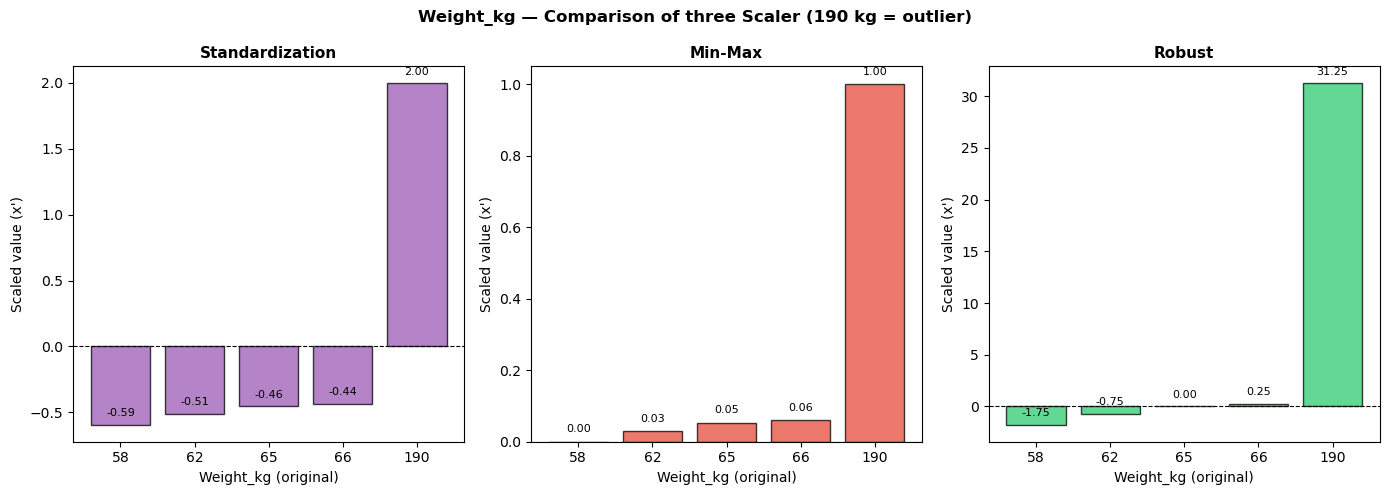

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

methods = ['Standardization', 'Min-Max', 'Robust']
values = [w_std_all, w_minmax, w_robust]
colors = ['#9b59b6', '#e74c3c', '#2ecc71']
labels = [str(int(w)) for w in weight]

for ax, method, vals, color in zip(axes, methods, values, colors):
    bars = ax.bar(labels, vals, color=color, alpha=0.75, edgecolor='black')
    ax.set_title(f'{method}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Weight_kg (original)')
    ax.set_ylabel("Scaled value (x')")
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02 * (max(vals) - min(vals)),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Weight_kg — Comparison of three Scaler (190 kg = outlier)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Min-Max**: 58–66 kg-এর সব bar প্রায় 0-এর কাছে — পার্থক্য বোঝাই যাচ্ছে না।
- **Standardization**: কিছুটা ভালো, কিন্তু outlier mean-কে টেনে নিয়েছে।
- **Robust**: 58–66 kg-এর মানগুলোর মধ্যে **পরিষ্কার পার্থক্য** দেখা যাচ্ছে — outlier আলাদা আছে।


---